In [ ]:
import subprocess
import os
import sys
import matplotlib.pyplot as plt
import pandas
import numpy as np
import subprocess
import ffi_wrapper

In [2]:
SEED = 42

In [ ]:
lib.fix_capacite_flow(p_reseau, 3.0, 2.0)
lib.ajout_source_destination(p_reseau)
lib.ajout_capacite_demande(p_reseau, 1.0)
lib.ajout_capacite_source(p_reseau, 1.0)
lib.nullifier_flow(p_reseau)

lib.compute_flow_ford_fukerson(p_reseau)


lib.print_graph_details(p_reseau, 2.0, 3.0)

lib.export_flow_matrix(p_reseau, b"output_algo.txt", 1)
lib.free_graph(p_reseau)
lib.fermeture_free_project(p_projet)



                  ÉTAT DU RÉSEAU (Temps: 0 s)                         
Sommets : 87 | Arcs : 214
Demande Globale : 32075.22 | Satisfaisabilité : 99.78%
Pression requise : 5.00 | Exposant : 0.50
Multiplicateur global de demande : 1.0000
Vitesse max Reservoir : 180.0000 m/min | arcs : 120.0000 m/min
-------------------------------------------------------------------------------------

--- LISTE DES SOMMETS ---
ID    | Type         | Elev.    | Demande      | Press.   | Degré
1     | JONCTION     | 9.75     | 3134.2358    | 4.75     | 1    
2     | JONCTION     | 3.81     | 6588.4319    | 24.09    | 1    
3     | JONCTION     | 0.00     | 0.0000       | 55.18    | 2    
4     | JONCTION     | 0.00     | 0.0000       | 55.18    | 2    
5     | JONCTION     | 12.80    | 56.4882      | 14.67    | 2    
6     | JONCTION     | 13.11    | 441.3285     | 14.35    | 2    
7     | JONCTION     | 8.69     | 955.0027     | 18.93    | 3    
8     | JONCTION     | 6.71     | 385.0479     | 20.91    |

In [ ]:
def extraire_arcs_orientes_dominants(graph_ptr):
    active_set = set()

    nb_tuyaux = graph_ptr.nb_arcs // 2
    
    for k in range(nb_tuyaux):
        idx_aller = 2 * k
        idx_retour = 2 * k + 1
        
        flow_aller = graph_ptr.arcs[idx_aller].flow
        flow_retour = graph_ptr.arcs[idx_retour].flow
        
        if flow_aller > 0 or flow_retour > 0:
            if flow_aller > flow_retour:
                active_set.add(idx_aller)
            elif flow_retour > flow_aller:
                active_set.add(idx_retour)
            
    return active_set

def extraire_tuyaux_physiques_actifs(graph_ptr):
    active_set = set()
    nb_tuyaux = graph_ptr.nb_arcs // 2
    
    for k in range(nb_tuyaux):
        flow_aller = graph_ptr.arcs[2 * k].flow
        flow_retour = graph_ptr.arcs[2 * k + 1].flow
        
        if flow_aller != flow_retour and (flow_aller > 0 or flow_retour > 0):
            active_set.add(k)
            
    return active_set


def jaccard_distance_non_symmetrique(graph1_ptr, graph2_ptr):
    active1 = extraire_arcs_orientes_dominants(graph1_ptr)
    active2 = extraire_arcs_orientes_dominants(graph2_ptr)
    
    union = len(active1 | active2)
    if union == 0:
        return 0.0
        
    intersection = len(active1 & active2)
    return 1.0 - (intersection / union)


def jaccard_distance_symmetrique(graph1_ptr, graph2_ptr):
    active1 = extraire_tuyaux_physiques_actifs(graph1_ptr)
    active2 = extraire_tuyaux_physiques_actifs(graph2_ptr)
    
    union = len(active1 | active2)
    if union == 0:
        return 0.0
        
    intersection = len(active1 & active2)
    return 1.0 - (intersection / union)

# COMPARAISON jaccard MULTIPLCATEUR algo FF


In [6]:
multipliers_source = np.array([1.0])
multipliers_destination_epa = np.array([1.0])
multipliers_destination = np.linspace(0.001, 15.0, 1000)
VITESSE_RESERVOIR = 3.0
VITESSE_ARCS = 2.0
symm = False

In [7]:
def create_graph_hamming_mult(symm, file_input, multipliers_source, multipliers_destination, multipliers_destination_epa, vitesse_reservoir, vitesse_arcs, type_analyse):
    distances = []
    multipliers = []
    algo_satisfactions = []

    for mult_source in multipliers_source:
        for mult_destination in multipliers_destination:
            for mult_destination_epa in multipliers_destination_epa:
                commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {mult_destination} {mult_destination_epa} {vitesse_reservoir} {vitesse_arcs} {type_analyse} {SEED} 0']
                resultat = subprocess.run(commande, capture_output=True, text=True)

                result, arcs, n, efficacite, sym_arcs, arcs_non_nulles = parser('output_epanet.txt')
                result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo, arcs_non_nulles_algo = parser('output_algo.txt')

                if symm:
                    dist = jaccard_distance_symmetrique(result, result_algo)
                else:
                    dist = jaccard_distance_non_symmetrique(result, result_algo)
                distances.append(dist)
                multipliers.append(mult_destination)
                algo_satisfactions.append(efficacite_algo)

    fig, ax = plt.subplots()
    sc = ax.scatter(multipliers, distances, c=algo_satisfactions, cmap='viridis', s=20)
    ax.set_xlabel('Multiplier')
    ax.set_ylabel('jaccard Distance')
    ax.set_title('jaccard Distance vs. Multiplier')
    ax.grid(True)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Satisfaction algorithme')

    # Add number of nodes and arcs at top right
    ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs_non_nulles}', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

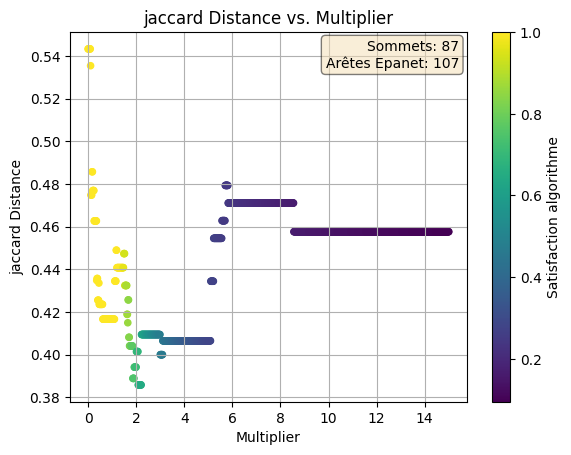

In [8]:
create_graph_hamming_mult(symm, 'net3_1s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

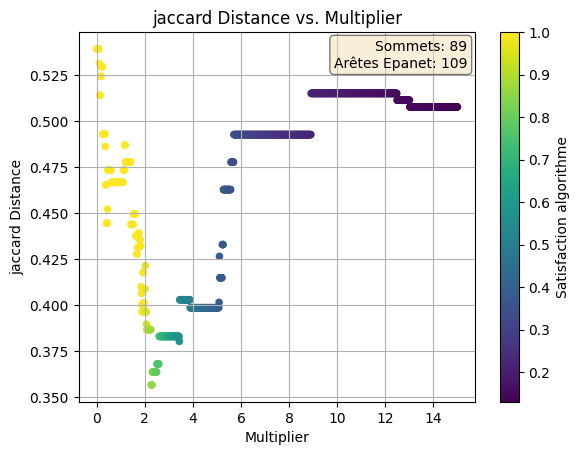

In [9]:
create_graph_hamming_mult(symm, 'net3_2s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

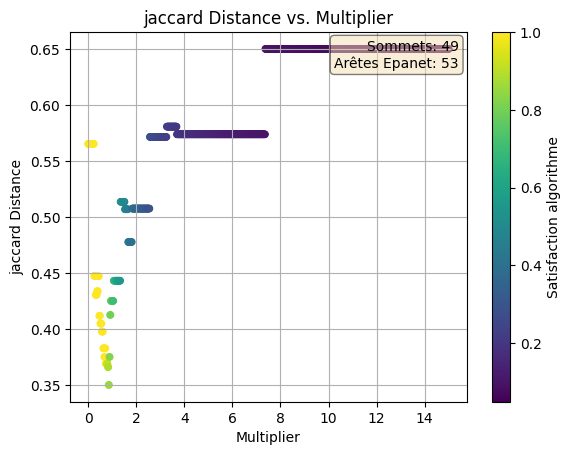

In [10]:
create_graph_hamming_mult(symm, 'generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

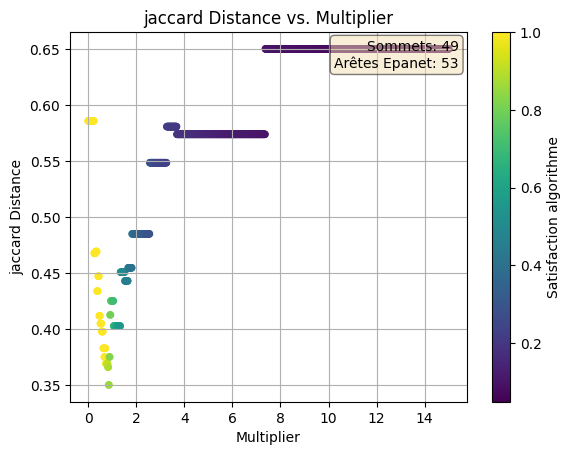

In [11]:
create_graph_hamming_mult(symm, 'generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)


# COMPARAISON satifaisabilite en fonction multiplicateur


In [12]:
multipliers_source = np.array([1.0])
multipliers_destination_epa = np.linspace(0.01, 50.0, 1000)
multipliers_destination = np.array([1.0])
VITESSE_RESERVOIR = 3.0
VITESSE_ARCS = 2.0
symm = True

In [13]:
def create_graph_jaccard_satisf(symm, file_input, multipliers_source, multipliers_destination, multipliers_destination_epa, vitesse_reservoir, vitesse_arcs, type_analyse):
    distances = []
    satisfactions = []
    mults = []

    for mult_source in multipliers_source:
        for mult_destination_epa in multipliers_destination_epa:
            commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {1/mult_destination_epa} {mult_destination_epa} {vitesse_reservoir} {vitesse_arcs} {type_analyse} {SEED} 0']
            resultat = subprocess.run(commande, capture_output=True, text=True)

            result, arcs, n, efficacite, sym_arcs, arcs_non_nulles = parser('output_epanet.txt')
            result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo, arcs_non_nulles_algo = parser('output_algo.txt')

            if symm:
                dist = jaccard_distance_symmetrique(result, result_algo)
            else:
                dist = jaccard_distance_non_symmetrique(result, result_algo)
            distances.append(dist)
            satisfactions.append(efficacite)
            mults.append(mult_destination_epa)

    if resultat.returncode != 0:
        print("Erreur d'exécution C :", resultat.stdout)
        print(resultat.stderr)

    fig, ax = plt.subplots()
    sc = ax.scatter(satisfactions, distances, c=mults, cmap='viridis', s=20)
    ax.set_xlabel('Taux de satisfaction EPANET')
    ax.set_ylabel('Distance de Jaccard')
    ax.set_title('Satisfaction EPANET en fonction de la distance de Jaccard')
    ax.grid(True)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Multiplicateur destination')

    ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs_non_nulles}', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

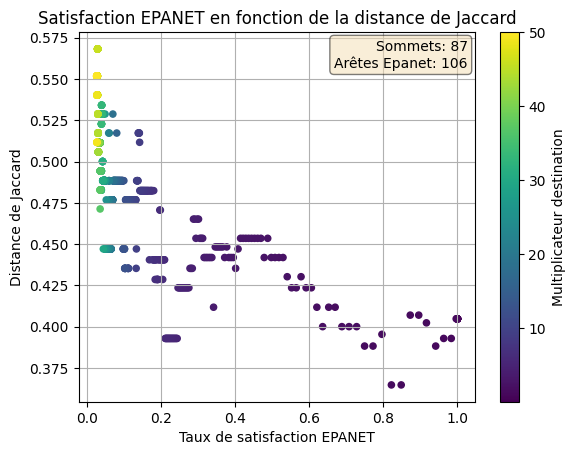

In [14]:
create_graph_jaccard_satisf(symm, 'net3_1s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

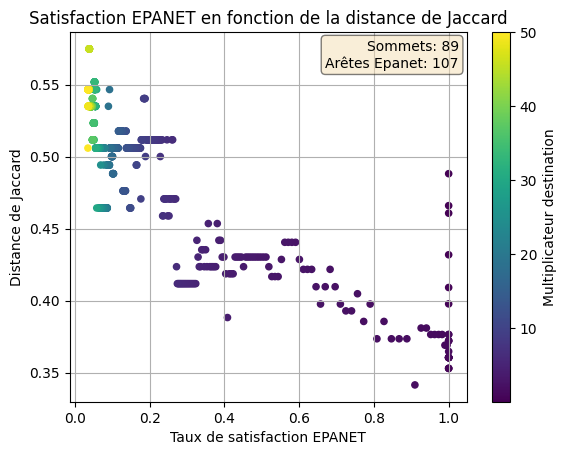

In [15]:
create_graph_jaccard_satisf(symm, 'net3_2s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

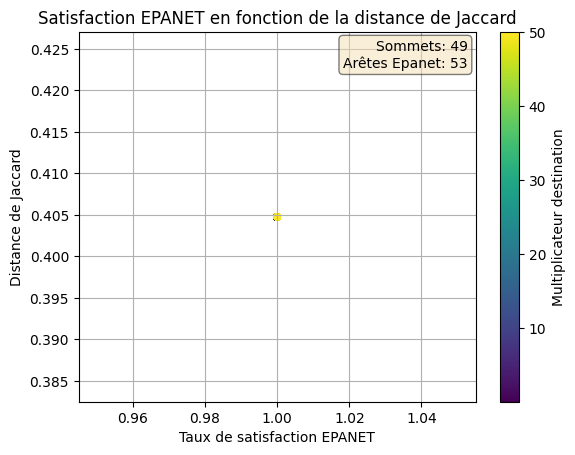

In [16]:
create_graph_jaccard_satisf(symm, 'generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

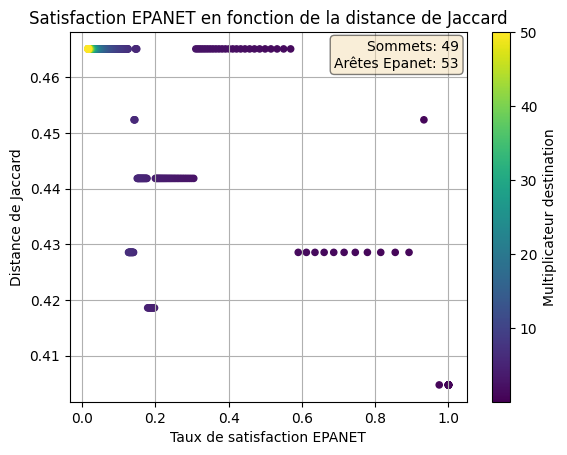

In [17]:
create_graph_jaccard_satisf(symm, 'generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 1)

# Efficacite EPA vs Efficacite FF

In [18]:
multipliers_source = np.array([1.0])
multipliers_destination_epa = np.linspace(0.01, 10.0, 1000)
multipliers_destination = np.array([1.0])
VITESSE_RESERVOIR = 3.0
VITESSE_ARCS = 2.0
symm = True

In [19]:
def create_graph_efficacite(file_input, multipliers_source, multipliers_destination, multipliers_destination_epa, vitesse_reservoir, vitesse_arcs, type_analyse):
    epanet_effs = []
    algo_effs = []
    jaccard_distances = []

    for mult_source in multipliers_source:
        for mult_destination in multipliers_destination:
            for mult_destination_epa in multipliers_destination_epa:
                commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {mult_destination} {mult_destination_epa} {vitesse_reservoir} {vitesse_arcs} {type_analyse} {SEED} 1']
                resultat = subprocess.run(commande, capture_output=True, text=True)

                result, arcs, n, efficacite, sym_arcs, arcs_non_nulles = parser('output_epanet.txt')
                result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo, arcs_non_nulles_algo = parser('output_algo.txt')

                epanet_effs.append(efficacite)
                algo_effs.append(efficacite_algo)
                dist = jaccard_distance_symmetrique(result, result_algo)
                jaccard_distances.append(dist)

    fig, ax = plt.subplots()
    sc = ax.scatter(epanet_effs, algo_effs, c=jaccard_distances, cmap='viridis', s=20)
    ax.set_xlabel('Efficacité EPANET')
    ax.set_ylabel("Efficacité algorithme")
    ax.set_title("Efficacité EPANET vs Efficacité algorithme")
    ax.grid(True)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Distance de Jaccard')

    ax.text(0.98, 0.02,
            f'Sommets: {n}\nArêtes Epanet: {arcs_non_nulles}',
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

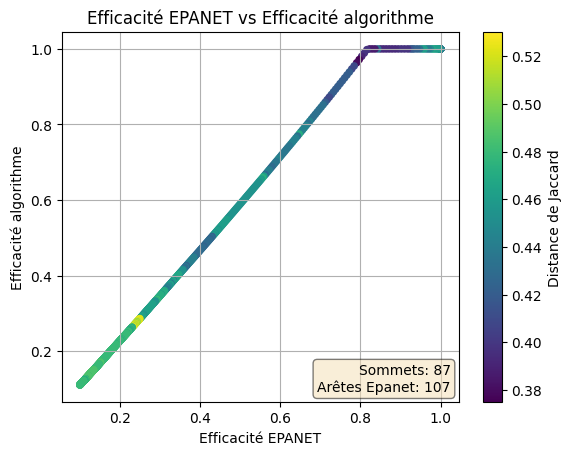

In [20]:
create_graph_efficacite('net3_1s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 2)

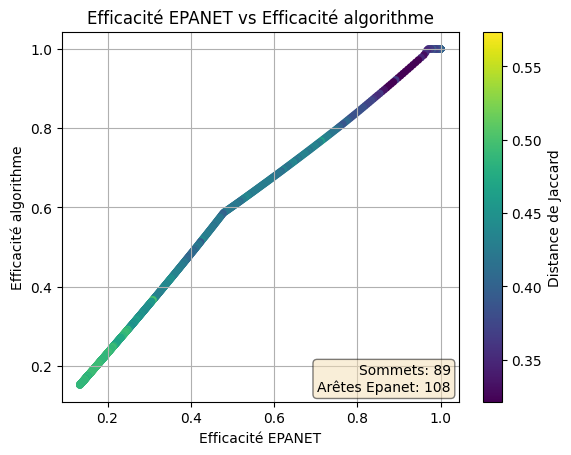

In [21]:
create_graph_efficacite('net3_2s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 2)

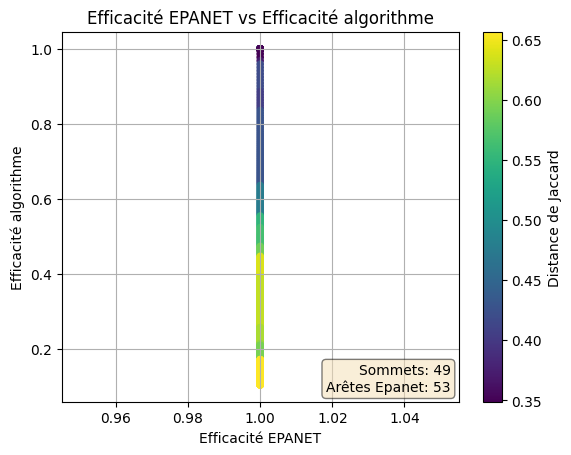

In [22]:
create_graph_efficacite('generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 2)

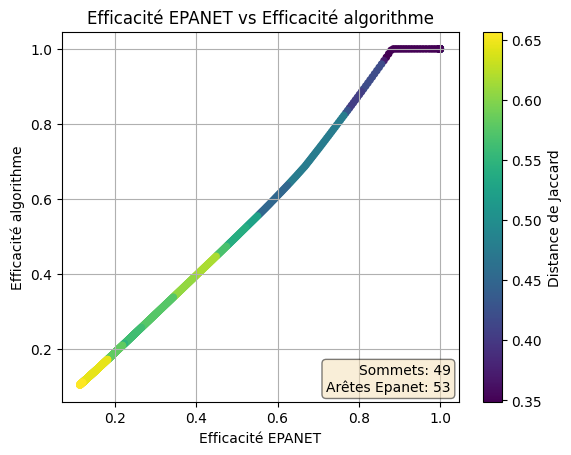

In [23]:
create_graph_efficacite('generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS, 2)

# COMPARE FLOW AVEC LES ORIENTATIONS CONNUES

In [24]:
def mean_flow_difference(m1, m2, arcs_non_nulles):
    diff = np.sum(np.abs(m1 - m2))
    vs = np.sum(m1 + m2)
    return diff / vs if vs > 0 else 0.0

In [25]:
multipliers_source = np.array([1.0])
multipliers_destination_epa = np.linspace(0.01, 50.0, 1000)
multipliers_destination = np.array([1.0])
VITESSE_RESERVOIR = 3.0
VITESSE_ARCS = 2.0
symm = True

In [26]:
def create_graph_diff_flow(symm, file_input, multipliers_source, multipliers_destination, multipliers_destination_epa, vitesse_reservoir, vitesse_arcs):
    flow_differences = []
    multipliers = []
    algo_satisfactions = []

    for mult_source in multipliers_source:
        for mult_destination in multipliers_destination:
            for mult_destination_epa in multipliers_destination_epa:
                commande = ["make", "run", f'ARGS={file_input} output_epanet.txt output_algo.txt {mult_source} {mult_destination} {mult_destination_epa} {vitesse_reservoir} {vitesse_arcs} 3 {SEED} 0']
                resultat = subprocess.run(commande, capture_output=True, text=True)

                result, arcs, n, efficacite, sym_arcs, arcs_non_nulles = parser('output_epanet.txt')
                result_algo, arcs_algo, n_algo, efficacite_algo, sym_arcs_algo, arcs_non_nulles_algo = parser('output_algo.txt')

                # Calcul de la différence moyenne entre les flows
                diff_flow = mean_flow_difference(result, result_algo, arcs_non_nulles)
                flow_differences.append(diff_flow)
                multipliers.append(mult_destination_epa)
                algo_satisfactions.append(efficacite_algo)

    fig, ax = plt.subplots()
    sc = ax.scatter(multipliers, flow_differences, c=algo_satisfactions, cmap='viridis', s=20)
    ax.set_xlabel('Multiplier')
    ax.set_ylabel('Différence moyenne des flows')
    ax.set_title('Différence moyenne des flows vs. Multiplier')
    ax.grid(True)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Satisfaction algorithme')

    # Add number of nodes and arcs at top right
    ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes Epanet: {arcs_non_nulles}', 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

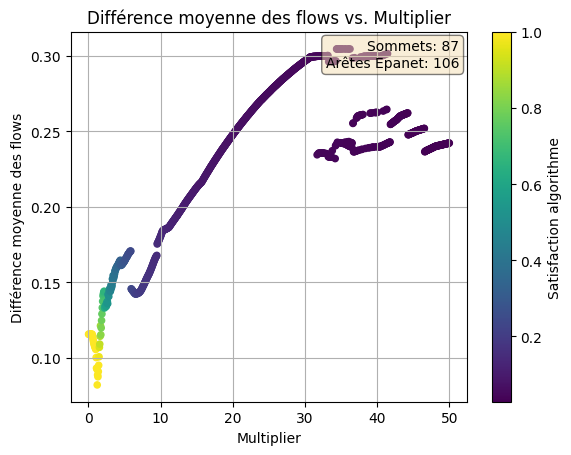

In [27]:
create_graph_diff_flow(1, 'net3_1s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS)

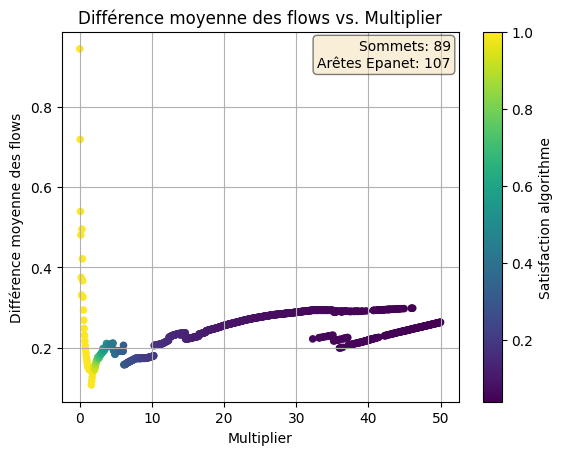

In [28]:
create_graph_diff_flow(1, 'net3_2s.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS)

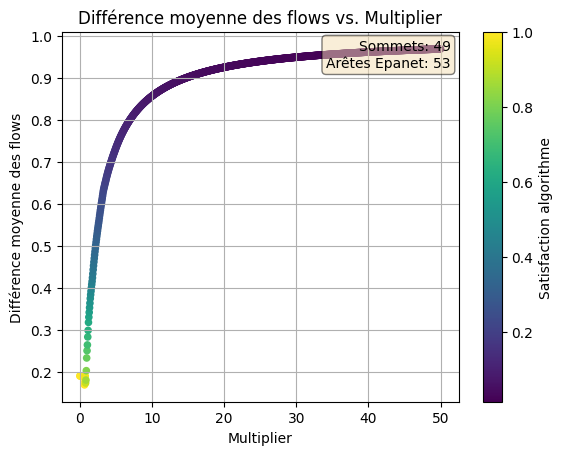

In [29]:
create_graph_diff_flow(1, 'generated_2s_demandes_satisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS)

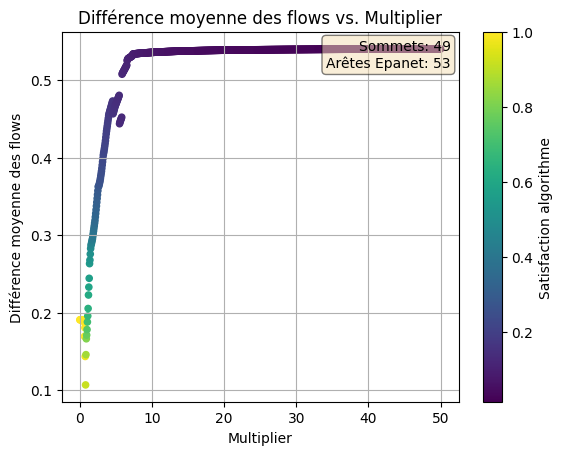

In [30]:
create_graph_diff_flow(1, 'generated_2s_demandes_insatisfaites.inp', multipliers_source, multipliers_destination, multipliers_destination_epa, VITESSE_RESERVOIR, VITESSE_ARCS)